# 🍽️ Dining Insights During Global Events: Event-Based Dining Trend Analysis
### MR603 Thesis — Multimodal AI Framework

---
### 📋 Notebook Overview
This notebook implements a **multimodal analysis pipeline** for dining trend analysis during global events (Olympics, FIFA World Cup). It covers:
1. Environment setup (CERN LCG / cvmfs compatible)
2. Dataset loading & exploration (Food-101, Tokyo Olympics Tweets, FIFA Tweets, Yelp Reviews)
3. Text preprocessing & NLP (BERT-based sentiment + BERTopic)
4. Image preprocessing & classification (ResNet-50 / ViT)
5. Multimodal fusion
6. Evaluation & visualisation
7. Interpretability (SHAP + Grad-CAM)

**Datasets used:**
- 🐦 [Tokyo Olympics 2020 Tweets](https://www.kaggle.com/datasets/gpreda/tokyo-olympics-2020-tweets)
- 🐦 [FIFA World Cup 2022 Tweets](https://www.kaggle.com/datasets/tirendazacademy/fifa-world-cup-2022-tweets)
- 🍕 [Food-101 Images](https://huggingface.co/datasets/ethz/food101)
- ⭐ [Yelp Reviews](https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset)

> **Note:** This notebook is configured for **CERN LCG / cvmfs** environments with read-only system site-packages. All installs use `--user` flag.

---
## 📦 Section 1: Environment Setup (CERN LCG Compatible)

In [1]:
import sys
import os
import site

# ── Make user-installed binaries & packages accessible ──────────────────
user_bin  = os.path.expanduser('~/.local/bin')
user_site = site.getusersitepackages()

if user_bin not in os.environ.get('PATH', ''):
    os.environ['PATH'] = user_bin + ':' + os.environ.get('PATH', '')

if user_site not in sys.path:
    sys.path.insert(0, user_site)

print(f'✅ PATH includes: {user_bin}')
print(f'✅ sys.path includes: {user_site}')
print(f'✅ Python executable: {sys.executable}')

✅ PATH includes: /eos/user/r/rpaudel/.local/bin
✅ sys.path includes: /eos/user/r/rpaudel/.local/lib/python3.12/site-packages
✅ Python executable: /cvmfs/sft.cern.ch/lcg/views/LCG_108_cuda/x86_64-el9-gcc13-opt/bin/python3


In [2]:
# ── Install all required packages to user directory ──────────────────────
# Using --user flag because /cvmfs is read-only on CERN systems

packages = [
    'kaggle',
    'transformers',
    'datasets',
    'scikit-learn',
    'bertopic',
    'umap-learn',
    'hdbscan',
    'shap',
    'grad-cam',
    'wordcloud',
    'plotly',
    'kaleido',
    'tqdm'
]

for pkg in packages:
    ret = os.system(f'{sys.executable} -m pip install --user {pkg} -q')
    status = '✅' if ret == 0 else '⚠️'
    print(f'{status} {pkg}')

# Reload sys.path so newly installed packages are importable immediately
import importlib
import site as _site
importlib.reload(_site)
user_site = _site.getusersitepackages()
if user_site not in sys.path:
    sys.path.insert(0, user_site)

print('\n✅ All installations complete.')

✅ kaggle
✅ transformers
✅ datasets
✅ scikit-learn
✅ bertopic
✅ umap-learn
✅ hdbscan
✅ shap
✅ grad-cam
✅ wordcloud
✅ plotly
✅ kaleido
✅ tqdm

✅ All installations complete.


In [3]:
# ── Core imports ─────────────────────────────────────────────────────────
import json
import re
import glob
import gzip
import pathlib
import warnings
import unicodedata
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from wordcloud import WordCloud
import plotly.express as px

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

# HuggingFace
from datasets import load_dataset
from transformers import (
    BertTokenizer, BertModel, BertForSequenceClassification,
    ViTForImageClassification, ViTImageProcessor,
    pipeline, TrainingArguments, Trainer
)

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_absolute_error
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device      : {device}')
print(f'✅ PyTorch     : {torch.__version__}')
if torch.cuda.is_available():
    print(f'✅ GPU         : {torch.cuda.get_device_name(0)}')
    print(f'✅ VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Output directory
os.makedirs('./outputs', exist_ok=True)
os.makedirs('./models',  exist_ok=True)
os.makedirs('./data/olympics', exist_ok=True)
os.makedirs('./data/fifa',     exist_ok=True)
os.makedirs('./data/yelp',     exist_ok=True)
print('✅ Output dirs : ./outputs/, ./models/, ./data/')

Matplotlib is building the font cache; this may take a moment.
2026-03-01 12:47:07.653179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772365627.671509     634 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772365627.677408     634 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772365627.694484     634 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772365627.694520     634 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772365627.6

✅ Device      : cuda
✅ PyTorch     : 2.9.1+cu128
✅ GPU         : NVIDIA A100-PCIE-40GB MIG 2g.10gb
✅ VRAM        : 10.5 GB
✅ Output dirs : ./outputs/, ./models/, ./data/


---
## 📂 Section 2: Dataset Loading & Exploration

### 2.1 Kaggle API Setup
> Paste your Kaggle credentials below. Get them from https://www.kaggle.com/settings → API → Create New Token

In [4]:
# ── Kaggle credentials ───────────────────────────────────────────────────
# Replace these with your actual Kaggle username and API key
KAGGLE_USERNAME = 'rishikesh0523'   # ← replace
KAGGLE_KEY      = 'KGAT_1a249a6d6e253612007e0eb54e0df8b7'    # ← replace

# Write kaggle.json to ~/.kaggle/
kaggle_dir = pathlib.Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
creds_path = kaggle_dir / 'kaggle.json'
creds_path.write_text(json.dumps({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}))
creds_path.chmod(0o600)

# Authenticate using Kaggle Python API (no CLI needed)
import kaggle
kaggle.api.authenticate()
print('✅ Kaggle authenticated successfully')

✅ Kaggle authenticated successfully


### 2.2 Download All Kaggle Datasets

In [5]:
# ── Download Tokyo Olympics 2020 Tweets ──────────────────────────────────
print('Downloading Tokyo Olympics 2020 Tweets...')
kaggle.api.dataset_download_files(
    'gpreda/tokyo-olympics-2020-tweets',
    path='./data/olympics',
    unzip=True,
    quiet=False
)
print('✅ Olympics tweets downloaded')

# ── Download FIFA World Cup 2022 Tweets ──────────────────────────────────
print('\nDownloading FIFA World Cup 2022 Tweets...')
kaggle.api.dataset_download_files(
    'tirendazacademy/fifa-world-cup-2022-tweets',
    path='./data/fifa',
    unzip=True,
    quiet=False
)
print('✅ FIFA tweets downloaded')

# ── Download Yelp Reviews (only the review JSON — rest is very large) ────
print('\nDownloading Yelp reviews JSON...')
try:
    kaggle.api.dataset_download_file(
        'yelp-dataset/yelp-dataset',
        file_name='yelp_academic_dataset_review.json',
        path='./data/yelp',
        quiet=False
    )
    print('✅ Yelp reviews downloaded')
except Exception as e:
    print(f'⚠️  Yelp single-file download failed ({e}). Trying full dataset...')
    kaggle.api.dataset_download_files(
        'yelp-dataset/yelp-dataset',
        path='./data/yelp',
        unzip=True,
        quiet=False
    )
    print('✅ Yelp full dataset downloaded')

# ── Show downloaded files ─────────────────────────────────────────────────
print('\n── Downloaded files ──')
for folder in ['./data/olympics', './data/fifa', './data/yelp']:
    files = glob.glob(f'{folder}/**/*', recursive=True)
    print(f'  {folder}:')
    for f in files:
        size = os.path.getsize(f) / 1e6 if os.path.isfile(f) else 0
        print(f'    {f}  ({size:.1f} MB)')

Dataset URL: https://www.kaggle.com/datasets/gpreda/tokyo-olympics-2020-tweets


100%|██████████| 24.8M/24.8M [00:01<00:00, 14.3MB/s]



✅ Olympics tweets downloaded

Dataset URL: https://www.kaggle.com/datasets/tirendazacademy/fifa-world-cup-2022-tweets


100%|██████████| 1.38M/1.38M [00:00<00:00, 2.36MB/s]



✅ FIFA tweets downloaded

Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset


100%|██████████| 2.07G/2.07G [00:59<00:00, 37.1MB/s]



✅ Yelp reviews downloaded

── Downloaded files ──
  ./data/olympics:
    ./data/olympics/tokyo_2020_tweets.csv  (62.8 MB)
  ./data/fifa:
    ./data/fifa/fifa_world_cup_2022_tweets.csv  (4.5 MB)
  ./data/yelp:
    ./data/yelp/yelp_academic_dataset_review.json.zip  (2220.6 MB)


### 2.3 Load Tokyo Olympics 2020 Tweets
> **Structure:** `text`, `username`, `location`, `followers`, `date`, `hashtags`, `source`, `retweets`, `favorites`, `is_retweet`

In [6]:
# Auto-discover CSV file (handles any filename Kaggle may use)
olym_files = glob.glob('./data/olympics/**/*.csv', recursive=True)
if not olym_files:
    raise FileNotFoundError('No Olympics CSV found. Check download above.')
print(f'Found: {olym_files}')

olympics_df = pd.read_csv(olym_files[0])

print('='*60)
print('TOKYO OLYMPICS 2020 TWEETS — DATASET STRUCTURE')
print('='*60)
print(f'Shape      : {olympics_df.shape}')
print(f'Columns    : {list(olympics_df.columns)}')
print(f'\nData Types:\n{olympics_df.dtypes}')
print(f'\nMissing Values:\n{olympics_df.isnull().sum()}')
print(f'\nSample Records:')
olympics_df.head(3)

Found: ['./data/olympics/tokyo_2020_tweets.csv']
TOKYO OLYMPICS 2020 TWEETS — DATASET STRUCTURE
Shape      : (297011, 16)
Columns    : ['id', 'user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'hashtags', 'source', 'retweets', 'favorites', 'is_retweet']

Data Types:
id                   object
user_name            object
user_location        object
user_description     object
user_created         object
user_followers       object
user_friends         object
user_favourites      object
user_verified        object
date                 object
text                 object
hashtags             object
source               object
retweets            float64
favorites           float64
is_retweet           object
dtype: object

Missing Values:
id                       0
user_name           131073
user_location       169096
user_description    139701
user_created        136479
user_followers    

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1418888645105356803,Abhishek Srivastav,"Udupi, India",Trying to be mediocre in many things,2021-02-01 06:33:51,45.0,39.0,293.0,False,2021-07-24 10:59:49,Let the party begin\n#Tokyo2020,['Tokyo2020'],Twitter for Android,0.0,0.0,False
1,1418888377680678918,Saikhom Mirabai Channu🇮🇳,"Manipur, India",Indian weightlifter 48 kg category. Champion🏆,2018-04-07 10:10:22,5235.0,5.0,2969.0,False,2021-07-24 10:58:45,Congratulations #Tokyo2020 https://t.co/8OFKMs...,['Tokyo2020'],Twitter for Android,0.0,0.0,False
2,1418888260886073345,Big Breaking,Global,All breaking news related to Financial Market....,2021-05-29 08:51:25,3646.0,3.0,5.0,False,2021-07-24 10:58:17,Big Breaking Now \n\nTokyo Olympic Update \n\n...,NaN,Twitter for Android,0.0,1.0,False


Text column: "text"


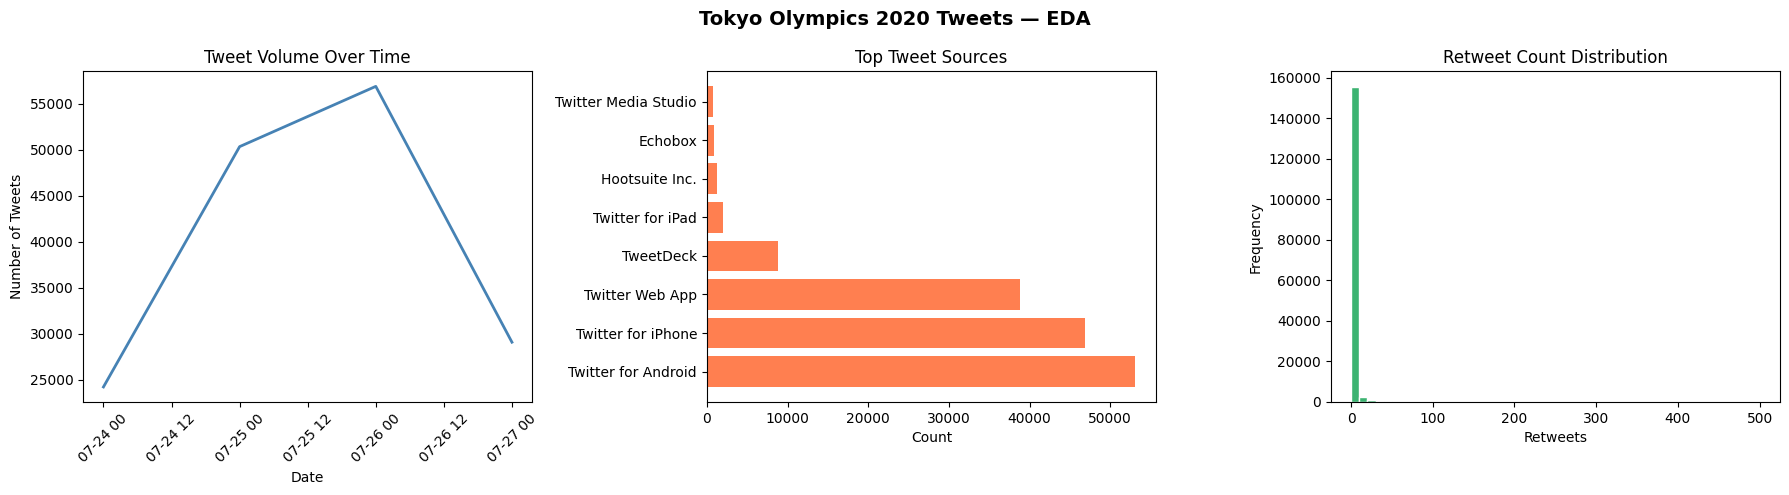

Total tweets: 297,011


In [7]:
# Identify the text column dynamically
olym_text_col = 'text' if 'text' in olympics_df.columns else olympics_df.columns[0]
print(f'Text column: "{olym_text_col}"')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tokyo Olympics 2020 Tweets — EDA', fontsize=14, fontweight='bold')

# 1. Tweet volume over time
if 'date' in olympics_df.columns:
    olympics_df['date'] = pd.to_datetime(olympics_df['date'], errors='coerce')
    tweet_by_date = olympics_df.groupby(olympics_df['date'].dt.date).size()
    axes[0].plot(tweet_by_date.index, tweet_by_date.values, color='steelblue', linewidth=2)
    axes[0].set_title('Tweet Volume Over Time')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Number of Tweets')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No date column', ha='center', va='center')

# 2. Top sources
if 'source' in olympics_df.columns:
    top_sources = olympics_df['source'].value_counts().head(8)
    axes[1].barh(top_sources.index, top_sources.values, color='coral')
    axes[1].set_title('Top Tweet Sources')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No source column', ha='center', va='center')

# 3. Retweet distribution
rt_col = next((c for c in ['retweets', 'retweet_count', 'Retweet Count'] if c in olympics_df.columns), None)
if rt_col:
    axes[2].hist(olympics_df[rt_col].clip(upper=500), bins=50, color='mediumseagreen', edgecolor='white')
    axes[2].set_title('Retweet Count Distribution')
    axes[2].set_xlabel('Retweets')
    axes[2].set_ylabel('Frequency')
else:
    axes[2].text(0.5, 0.5, 'No retweet column', ha='center', va='center')

plt.tight_layout()
plt.savefig('./outputs/olympics_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total tweets: {len(olympics_df):,}')

### 2.4 Load FIFA World Cup 2022 Tweets
> **Structure:** `tweet`, `date`, `username`, `location`, `likes_count`, `retweet_count`, `lang`

In [8]:
# Auto-discover FIFA CSV files
fifa_files = glob.glob('./data/fifa/**/*.csv', recursive=True)
if not fifa_files:
    raise FileNotFoundError('No FIFA CSV found. Check download above.')
print(f'Found: {fifa_files}')

fifa_df = pd.concat([pd.read_csv(f) for f in fifa_files], ignore_index=True)

print('='*60)
print('FIFA WORLD CUP 2022 TWEETS — DATASET STRUCTURE')
print('='*60)
print(f'Shape      : {fifa_df.shape}')
print(f'Columns    : {list(fifa_df.columns)}')
print(f'\nData Types:\n{fifa_df.dtypes}')
print(f'\nMissing Values:\n{fifa_df.isnull().sum()}')
fifa_df.head(3)

Found: ['./data/fifa/fifa_world_cup_2022_tweets.csv']
FIFA WORLD CUP 2022 TWEETS — DATASET STRUCTURE
Shape      : (22524, 6)
Columns    : ['Unnamed: 0', 'Date Created', 'Number of Likes', 'Source of Tweet', 'Tweet', 'Sentiment']

Data Types:
Unnamed: 0          int64
Date Created       object
Number of Likes     int64
Source of Tweet    object
Tweet              object
Sentiment          object
dtype: object

Missing Values:
Unnamed: 0         0
Date Created       0
Number of Likes    0
Source of Tweet    0
Tweet              0
Sentiment          0
dtype: int64


,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive


In [9]:
# ── Merge both tweet datasets into a unified schema ──────────────────────
def standardize_tweets(df, text_col, source_name):
    """Rename text column and tag event source."""
    df = df.copy()
    if text_col != 'text':
        df = df.rename(columns={text_col: 'text'})
    df['event_source'] = source_name
    keep = [c for c in ['text', 'date', 'username', 'location',
                         'retweets', 'favorites', 'likes_count',
                         'retweet_count', 'lang', 'event_source']
            if c in df.columns]
    return df[keep]

# Detect text column for each dataset
olym_text_col = 'text'  if 'text'  in olympics_df.columns else olympics_df.columns[0]
fifa_text_col = 'tweet' if 'tweet' in fifa_df.columns else \
                'text'  if 'text'  in fifa_df.columns else fifa_df.columns[0]

olym_std = standardize_tweets(olympics_df, olym_text_col, 'Tokyo_Olympics_2020')
fifa_std  = standardize_tweets(fifa_df,    fifa_text_col,  'FIFA_WorldCup_2022')

all_tweets = pd.concat([olym_std, fifa_std], ignore_index=True)
print(f'✅ Combined tweet dataset: {all_tweets.shape}')
all_tweets.head(3)

✅ Combined tweet dataset: (319535, 5)


,text,date,retweets,favorites,event_source
0,Let the party begin\n#Tokyo2020,2021-07-24 10:59:49,0.0,0.0,Tokyo_Olympics_2020
1,Congratulations #Tokyo2020 https://t.co/8OFKMs...,2021-07-24 10:58:45,0.0,0.0,Tokyo_Olympics_2020
2,Big Breaking Now \n\nTokyo Olympic Update \n\n...,2021-07-24 10:58:17,0.0,1.0,Tokyo_Olympics_2020


### 2.5 Load Yelp Reviews
> **Structure:** `review_id`, `user_id`, `business_id`, `stars`, `useful`, `funny`, `cool`, `text`, `date`  
> Used for: Fine-tuning BERT on restaurant review sentiment

In [11]:
import zipfile
import io

# Auto-detect Yelp review file — handles .json, .json.gz, and .zip
yelp_candidates = glob.glob('./data/yelp/**/yelp_academic_dataset_review*', recursive=True)
print(f'Yelp files found: {yelp_candidates}')

if not yelp_candidates:
    raise FileNotFoundError('Yelp review file not found. Check download above.')

yelp_path = yelp_candidates[0]
print(f'Loading from: {yelp_path}')

MAX_ROWS = 100_000
yelp_records = []

if yelp_path.endswith('.zip'):
    # Handle .zip (what Kaggle actually downloads)
    with zipfile.ZipFile(yelp_path, 'r') as zf:
        # Find the review JSON inside the zip
        json_files = [name for name in zf.namelist() if 'review' in name and name.endswith('.json')]
        print(f'Files inside zip: {zf.namelist()}')
        print(f'Review JSON found: {json_files}')
        if not json_files:
            raise FileNotFoundError(f'No review JSON inside zip. Contents: {zf.namelist()}')
        with zf.open(json_files[0]) as raw:
            reader = io.TextIOWrapper(raw, encoding='utf-8')
            for i, line in enumerate(reader):
                if i >= MAX_ROWS:
                    break
                line = line.strip()
                if line:
                    yelp_records.append(json.loads(line))

elif yelp_path.endswith('.gz'):
    import gzip
    with gzip.open(yelp_path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= MAX_ROWS:
                break
            line = line.strip()
            if line:
                yelp_records.append(json.loads(line))

else:
    # Plain .json
    with open(yelp_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= MAX_ROWS:
                break
            line = line.strip()
            if line:
                yelp_records.append(json.loads(line))

yelp_df = pd.DataFrame(yelp_records)

print('='*60)
print('YELP REVIEWS — DATASET STRUCTURE')
print('='*60)
print(f'Shape      : {yelp_df.shape}')
print(f'Columns    : {list(yelp_df.columns)}')
print(f'\nStar Distribution:\n{yelp_df["stars"].value_counts().sort_index()}')
print(f'\nMissing Values:\n{yelp_df.isnull().sum()}')
yelp_df.head(3)

Yelp files found: ['./data/yelp/yelp_academic_dataset_review.json.zip']
Loading from: ./data/yelp/yelp_academic_dataset_review.json.zip
Files inside zip: ['yelp_academic_dataset_review.json']
Review JSON found: ['yelp_academic_dataset_review.json']
YELP REVIEWS — DATASET STRUCTURE
Shape      : (100000, 9)
Columns    : ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']

Star Distribution:
stars
1.0    10921
2.0     7988
3.0    11362
4.0    25337
5.0    44392
Name: count, dtype: int64

Missing Values:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30


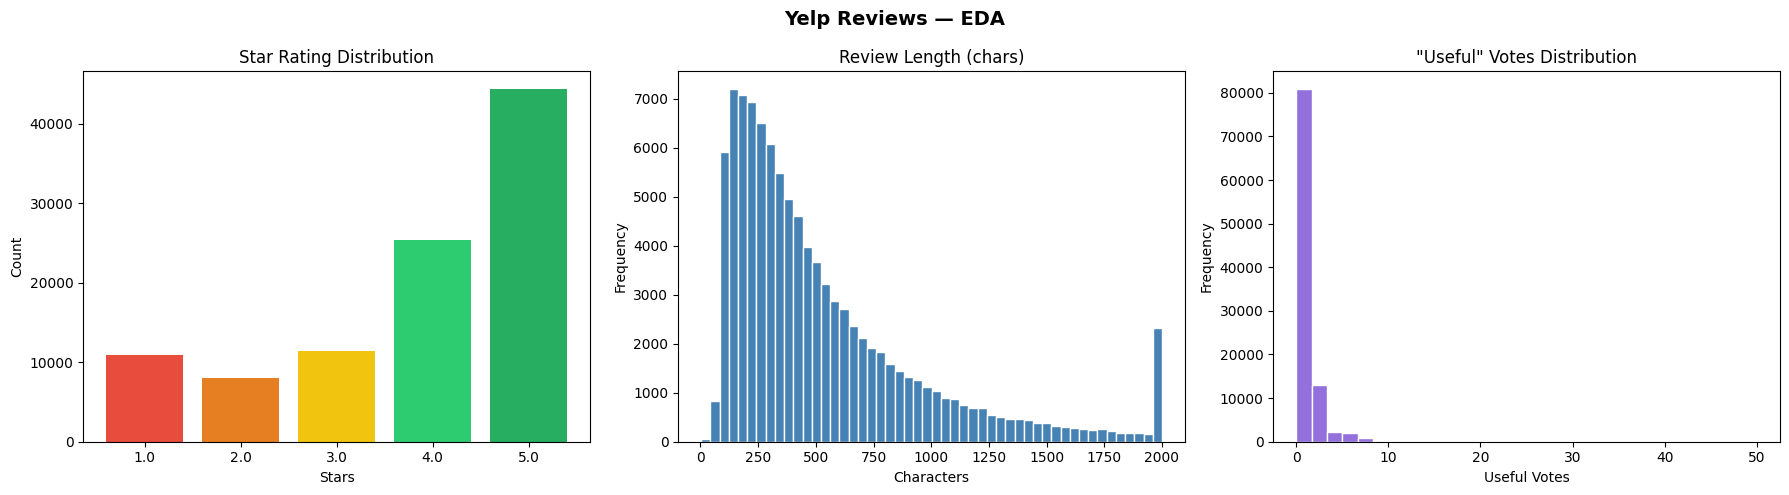

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Yelp Reviews — EDA', fontsize=14, fontweight='bold')

# 1. Star distribution
star_counts = yelp_df['stars'].value_counts().sort_index()
axes[0].bar(star_counts.index.astype(str), star_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0].set_title('Star Rating Distribution')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')

# 2. Review length
yelp_df['text_len'] = yelp_df['text'].str.len()
axes[1].hist(yelp_df['text_len'].clip(upper=2000), bins=50,
             color='steelblue', edgecolor='white')
axes[1].set_title('Review Length (chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

# 3. Useful votes
axes[2].hist(yelp_df['useful'].clip(upper=50), bins=30,
             color='mediumpurple', edgecolor='white')
axes[2].set_title('"Useful" Votes Distribution')
axes[2].set_xlabel('Useful Votes')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('./outputs/yelp_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Load Food-101 Image Dataset
> **Source:** https://huggingface.co/datasets/ethz/food101  
> **Structure:** `image` (PIL), `label` (int 0–100)  
> 101 classes × 1,000 images = 101,000 total | Split: 75,750 train / 25,250 test

In [13]:
# Streams from HuggingFace — no manual download needed
food101 = load_dataset('ethz/food101')

print('='*60)
print('FOOD-101 — DATASET STRUCTURE')
print('='*60)
print(f'Splits   : {food101}')
print(f'Train    : {len(food101["train"]):,} samples')
print(f'Test     : {len(food101["validation"]):,} samples')
print(f'Features : {food101["train"].features}')

label_names = food101['train'].features['label'].names
print(f'\nClasses  : {len(label_names)}')
print(f'Sample class names: {label_names[:15]}')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

FOOD-101 — DATASET STRUCTURE
Splits   : DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 75750
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 25250
    })
})
Train    : 75,750 samples
Test     : 25,250 samples
Features : {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_o

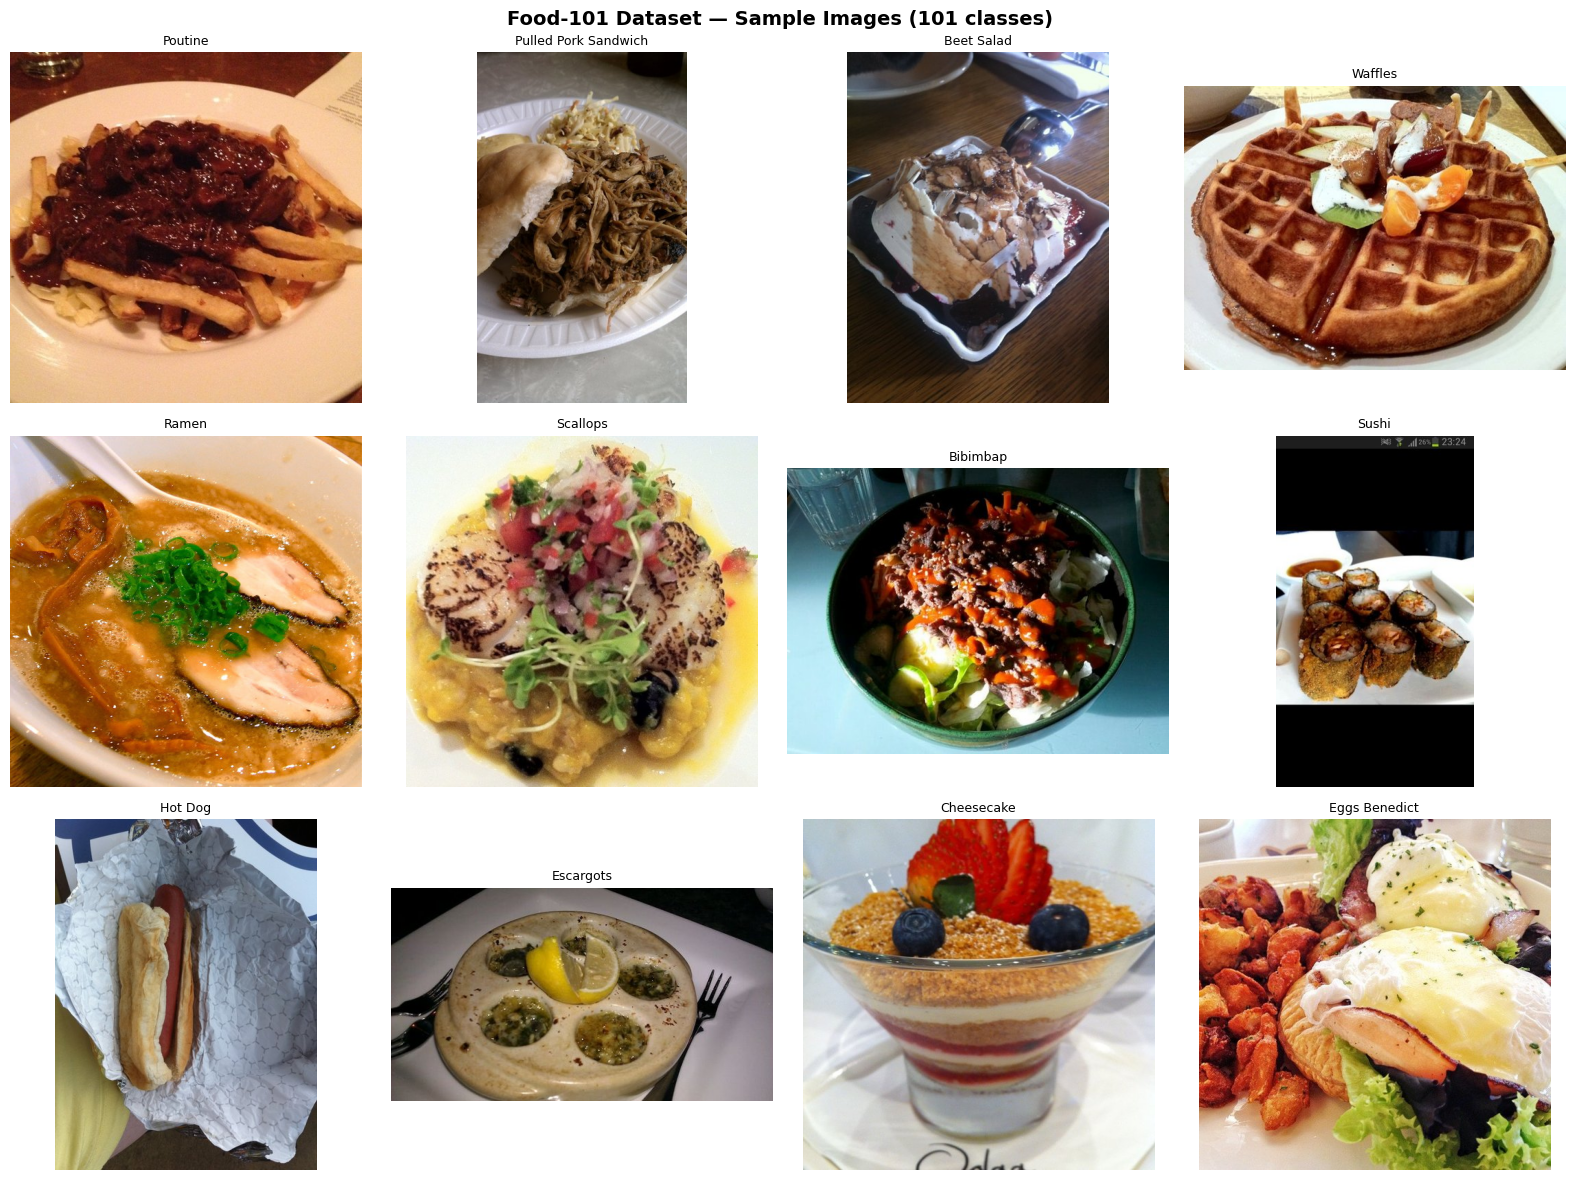


Class balance check (first 5050 samples):
  Min count: 550 | Max count: 750 → Balanced ✅


In [14]:
# Visualize 12 random sample images
sample_indices = random.sample(range(len(food101['train'])), 12)
samples = [food101['train'][i] for i in sample_indices]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Food-101 Dataset — Sample Images (101 classes)', fontsize=14, fontweight='bold')
for ax, sample in zip(axes.flatten(), samples):
    ax.imshow(sample['image'])
    ax.set_title(label_names[sample['label']].replace('_', ' ').title(), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/food101_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Check class balance
sample_labels = [food101['train'][i]['label'] for i in range(min(5050, len(food101['train'])))]
label_counts  = Counter(sample_labels)
print(f'\nClass balance check (first 5050 samples):')
print(f'  Min count: {min(label_counts.values())} | Max count: {max(label_counts.values())} → Balanced ✅')